# IBM Quantum Optimization Level Task

Compare transpilation optimization levels (0-3) using IBM Quantum simulators.

## Backend Selection

### Available IBM Fake Backends

All fake backends simulate real IBM Quantum systems using the BackendV2 interface.

**5 Qubit Systems:**
- FakeArmonkV2, FakeAthensV2, FakeBelemV2, FakeBogotaV2, FakeBurlingtonV2
- FakeEssexV2, FakeLimaV2, FakeLondonV2, FakeManilaV2, FakeOurenseV2
- FakeQuitoV2, FakeRomeV2, FakeValenciaV2, FakeVigoV2, FakeYorktownV2

**7 Qubit Systems:**
- FakeCasablancaV2, FakeJakartaV2, FakeLagosV2, FakeNairobiV2, FakeOslo, FakePerth

**15-27 Qubit Systems:**
- FakeMelbourneV2 (15), FakeGuadalupeV2 (16)
- FakeAlgiers, FakeAuckland, FakeCairoV2, FakeGeneva, FakeHanoiV2, FakeKolkataV2
- FakeMontrealV2, FakeMumbaiV2, FakePeekskill, FakeSydneyV2, FakeTorontoV2

**33 Qubit Systems:**
- FakePrague

**127-133 Qubit Systems:**
- FakeBrisbane, FakeCusco, FakeKawasaki, FakeKyiv, FakeKyoto, FakeOsaka
- FakeQuebec, FakeSherbrooke, FakeWashingtonV2, FakeTorino

In [ ]:
from ipywidgets import SelectMultiple, Button, VBox, Output
from IPython.display import display, clear_output
import warnings
warnings.filterwarnings('ignore')

# Lazy import function - only imports when backend is selected
def get_backend_class(name):
    from qiskit_ibm_runtime import fake_provider
    return getattr(fake_provider, name)

AVAILABLE_BACKENDS = {
    # 5 Qubit Systems
    'FakeArmonkV2 (5q)': 'FakeArmonkV2',
    'FakeAthensV2 (5q)': 'FakeAthensV2',
    'FakeBelemV2 (5q)': 'FakeBelemV2',
    'FakeBogotaV2 (5q)': 'FakeBogotaV2',
    'FakeManilaV2 (5q)': 'FakeManilaV2',
    'FakeQuitoV2 (5q)': 'FakeQuitoV2',
    'FakeRomeV2 (5q)': 'FakeRomeV2',
    # 7 Qubit Systems
    'FakeJakartaV2 (7q)': 'FakeJakartaV2',
    'FakeLagosV2 (7q)': 'FakeLagosV2',
    'FakePerth (7q)': 'FakePerth',
    # 15-27 Qubit Systems
    'FakeMelbourneV2 (15q)': 'FakeMelbourneV2',
    'FakeGuadalupeV2 (16q)': 'FakeGuadalupeV2',
    'FakeCairoV2 (27q)': 'FakeCairoV2',
    'FakeHanoiV2 (27q)': 'FakeHanoiV2',
    'FakeKolkataV2 (27q)': 'FakeKolkataV2'
}

backend_selector = SelectMultiple(
    options=list(AVAILABLE_BACKENDS.keys()),
    value=['FakeManilaV2 (5q)'],
    description='Backends:',
    disabled=False,
    rows=15,
    style={'description_width': '100px'},
    layout={'width': '600px'}
)

confirm_button = Button(
    description='Confirm Selection',
    button_style='success',
    icon='check',
    layout={'width': '200px'}
)

output = Output()
selected_backends = []

def on_confirm_click(b):
    global selected_backends
    with output:
        clear_output()
        selected = list(backend_selector.value)
        
        if len(selected) == 0:
            print("⚠️  Please select at least one backend!")
            selected_backends = []
            return
        
        print("⏳ Loading backends...")
        selected_backends = [get_backend_class(AVAILABLE_BACKENDS[name])() for name in selected]
        
        print("✅ Backend selection confirmed!")
        print("=" * 80)
        print(f"Selected {len(selected_backends)} backend(s):")
        for idx, backend in enumerate(selected_backends, 1):
            print(f"\n{idx}. {backend.name}")
            print(f"   Qubits: {backend.num_qubits}")
            print(f"   Coupling Map: {backend.coupling_map}")
        print("\n" + "=" * 80)

confirm_button.on_click(on_confirm_click)

print("SELECT IBM QUANTUM SIMULATORS (1 or more)")
print("=" * 80)
print("Tip: Hold Ctrl/Cmd to select multiple backends")
display(VBox([backend_selector, confirm_button, output]))

SELECT IBM QUANTUM SIMULATORS (1 or more)
Tip: Hold Ctrl/Cmd to select multiple backends


## Create Circuit

In [2]:
from qiskit import QuantumCircuit
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
import matplotlib.pyplot as plt
import numpy as np

if 'selected_backends' not in globals() or not selected_backends:
    print("❌ ERROR: Please select backend(s) first!")
else:
    NUM_QUBITS = 5
    ENTANGLEMENT_LAYERS = 2
    ROTATION_PARAMS = {'rz': 0.5, 'ry': 0.3}
    
    grover = QuantumCircuit(NUM_QUBITS, NUM_QUBITS)
    
    grover.h(range(NUM_QUBITS))
    
    for layer in range(ENTANGLEMENT_LAYERS):
        grover.cz(0, 1)
        grover.cz(1, 2)
        grover.cz(2, 3)
        grover.cz(3, 4)
        grover.cz(0, 4)
        grover.h(range(NUM_QUBITS))
    
    grover.x(range(NUM_QUBITS))
    grover.h(4)
    grover.mcx([0, 1, 2, 3], 4)
    grover.h(4)
    grover.x(range(NUM_QUBITS))
    grover.h(range(NUM_QUBITS))
    
    for i in range(NUM_QUBITS):
        grover.rz(ROTATION_PARAMS['rz'], i)
        grover.ry(ROTATION_PARAMS['ry'], i)
    
    for i in range(NUM_QUBITS - 1):
        grover.cx(i, i + 1)
    grover.cx(NUM_QUBITS - 1, 0)
    
    grover.h(range(NUM_QUBITS))
    grover.measure(range(NUM_QUBITS), range(NUM_QUBITS))

## Transpile and Execute

In [3]:
if 'selected_backends' not in globals() or not selected_backends:
    print("❌ ERROR: Please select backend(s) first!")
else:
    OPTIMIZATION_LEVELS = [0, 1, 2, 3]
    SHOTS = 4000
    
    backend_results = {}
    
    for backend in selected_backends:
        print(f"\nProcessing: {backend.name}")
        print("=" * 80)
        
        transpiled_circuits = {}
        results_dict = {}
        
        for level in OPTIMIZATION_LEVELS:
            print(f"\nLevel {level}:", end=" ")
            
            try:
                pm = generate_preset_pass_manager(
                    optimization_level=level, 
                    backend=backend,
                    seed_transpiler=42
                )
                
                transpiled_circuits[level] = pm.run(grover)
                circuit = transpiled_circuits[level]
                
                depth_reduction = (1 - circuit.depth() / grover.depth()) * 100
                gate_reduction = (1 - circuit.size() / grover.size()) * 100
                
                print(f"Depth={circuit.depth()} ({depth_reduction:+.1f}%), Gates={circuit.size()} ({gate_reduction:+.1f}%)")
                
                job = backend.run(circuit, shots=SHOTS)
                results_dict[level] = job.result().get_counts()
                
            except Exception as e:
                print(f"Error: {str(e)[:50]}")
                results_dict[level] = {}
        
        backend_results[backend.name] = {
            'transpiled_circuits': transpiled_circuits,
            'results_dict': results_dict
        }
    
    print("\n" + "=" * 80)
    print("✓ Transpilation complete!")
    print("=" * 80)


Processing: fake_bogota

Level 0: Depth=299 (-1007.4%), Gates=460 (-576.5%)

Level 1: Depth=194 (-618.5%), Gates=300 (-341.2%)

Level 2: Depth=199 (-637.0%), Gates=320 (-370.6%)

Level 3: Depth=199 (-637.0%), Gates=320 (-370.6%)

Processing: fake_jakarta

Level 0: Depth=250 (-825.9%), Gates=424 (-523.5%)

Level 1: Depth=190 (-603.7%), Gates=265 (-289.7%)

Level 2: Depth=195 (-622.2%), Gates=279 (-310.3%)

Level 3: Depth=195 (-622.2%), Gates=279 (-310.3%)

Processing: fake_lagos

Level 0: Depth=250 (-825.9%), Gates=424 (-523.5%)

Level 1: Depth=190 (-603.7%), Gates=265 (-289.7%)

Level 2: Depth=191 (-607.4%), Gates=277 (-307.4%)

Level 3: Depth=191 (-607.4%), Gates=277 (-307.4%)

✓ Transpilation complete!


## Metrics Analysis

STATISTICS - fake_bogota

Original: Depth=27, Gates=68

Transpiled:
  Level 0: Depth=299, Gates=460
  Level 1: Depth=194, Gates=300
  Level 2: Depth=199, Gates=320
  Level 3: Depth=199, Gates=320

TOP 5 RESULTS

Level 0:
  |10000⟩:  170 ( 4.25%) ██
  |11000⟩:  161 ( 4.03%) ██
  |10110⟩:  153 ( 3.82%) █
  |01000⟩:  153 ( 3.82%) █
  |00001⟩:  151 ( 3.77%) █

Level 1:
  |00010⟩:  171 ( 4.28%) ██
  |10000⟩:  159 ( 3.98%) █
  |01000⟩:  152 ( 3.80%) █
  |11100⟩:  148 ( 3.70%) █
  |00101⟩:  147 ( 3.67%) █

Level 2:
  |01000⟩:  165 ( 4.12%) ██
  |11100⟩:  157 ( 3.92%) █
  |10000⟩:  151 ( 3.77%) █
  |00100⟩:  145 ( 3.62%) █
  |10110⟩:  145 ( 3.62%) █

Level 3:
  |10000⟩:  175 ( 4.38%) ██
  |11100⟩:  161 ( 4.03%) ██
  |01000⟩:  156 ( 3.90%) █
  |11000⟩:  152 ( 3.80%) █
  |00000⟩:  152 ( 3.80%) █




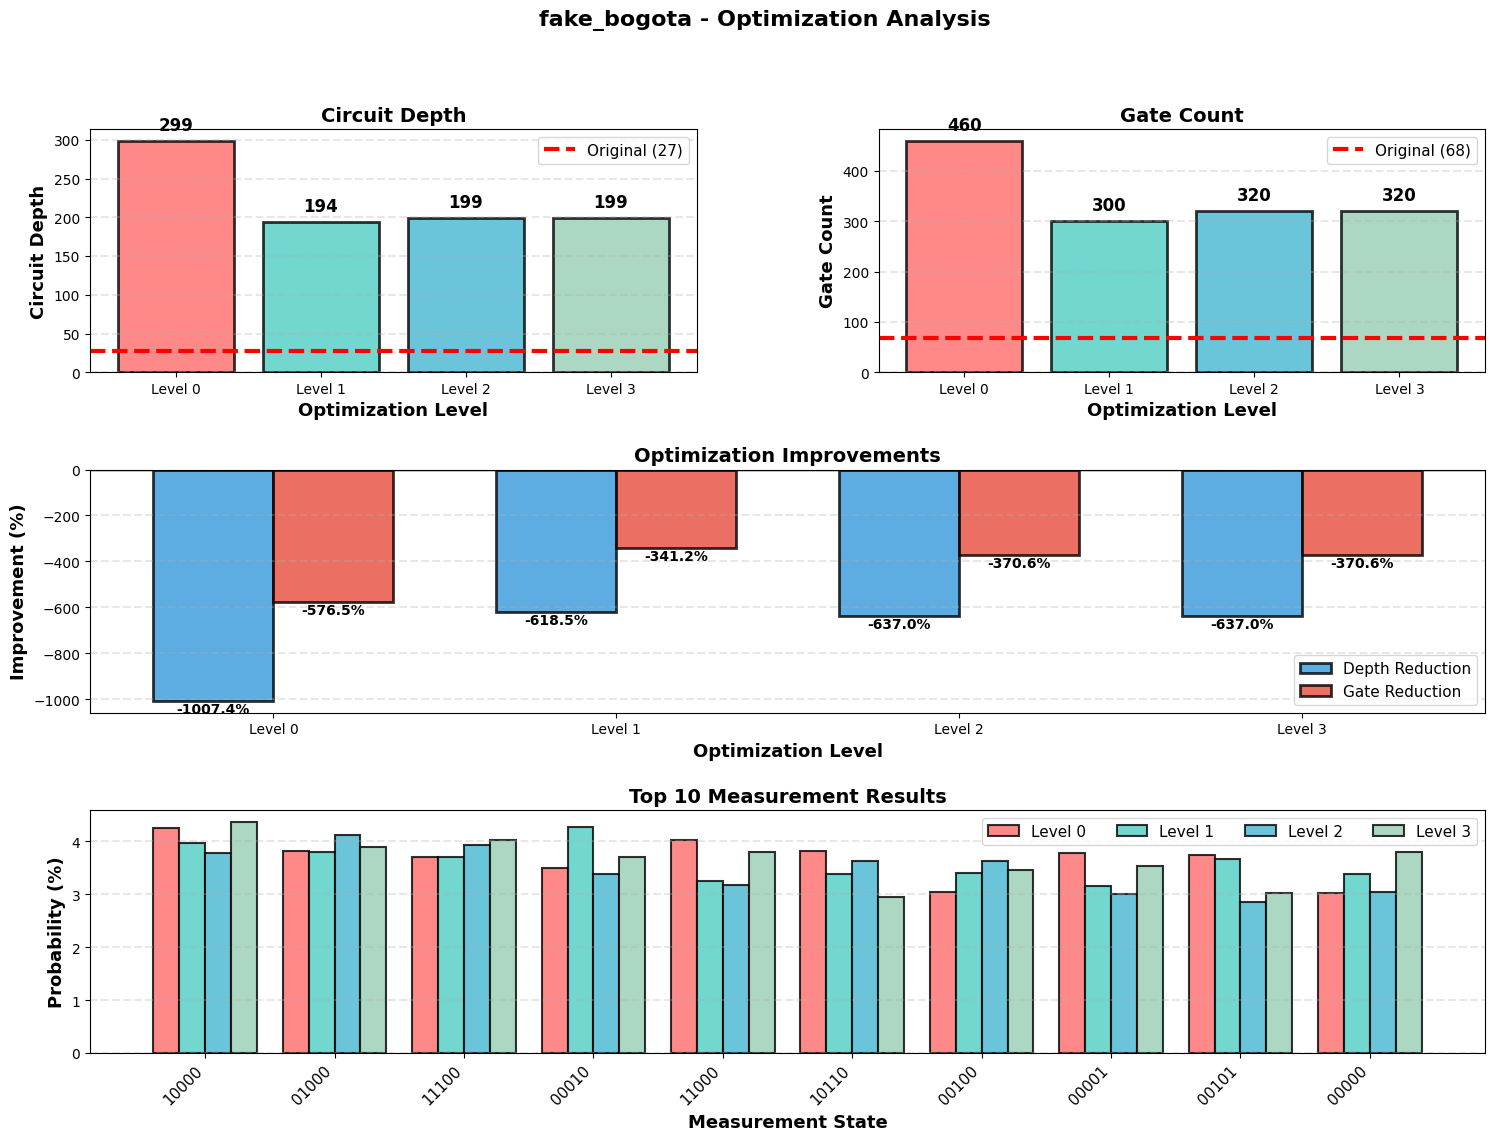

STATISTICS - fake_jakarta

Original: Depth=27, Gates=68

Transpiled:
  Level 0: Depth=250, Gates=424
  Level 1: Depth=190, Gates=265
  Level 2: Depth=195, Gates=279
  Level 3: Depth=195, Gates=279

TOP 5 RESULTS

Level 0:
  |10000⟩:  243 ( 6.08%) ███
  |00000⟩:  201 ( 5.03%) ██
  |00100⟩:  160 ( 4.00%) ██
  |10001⟩:  158 ( 3.95%) █
  |11000⟩:  155 ( 3.88%) █

Level 1:
  |00000⟩:  246 ( 6.15%) ███
  |10000⟩:  239 ( 5.97%) ██
  |10010⟩:  154 ( 3.85%) █
  |10001⟩:  146 ( 3.65%) █
  |01100⟩:  145 ( 3.62%) █

Level 2:
  |00000⟩:  267 ( 6.68%) ███
  |10000⟩:  263 ( 6.58%) ███
  |11000⟩:  178 ( 4.45%) ██
  |10010⟩:  157 ( 3.92%) █
  |00100⟩:  154 ( 3.85%) █

Level 3:
  |10000⟩:  268 ( 6.70%) ███
  |00000⟩:  241 ( 6.02%) ███
  |11000⟩:  169 ( 4.23%) ██
  |00001⟩:  157 ( 3.92%) █
  |10011⟩:  157 ( 3.92%) █




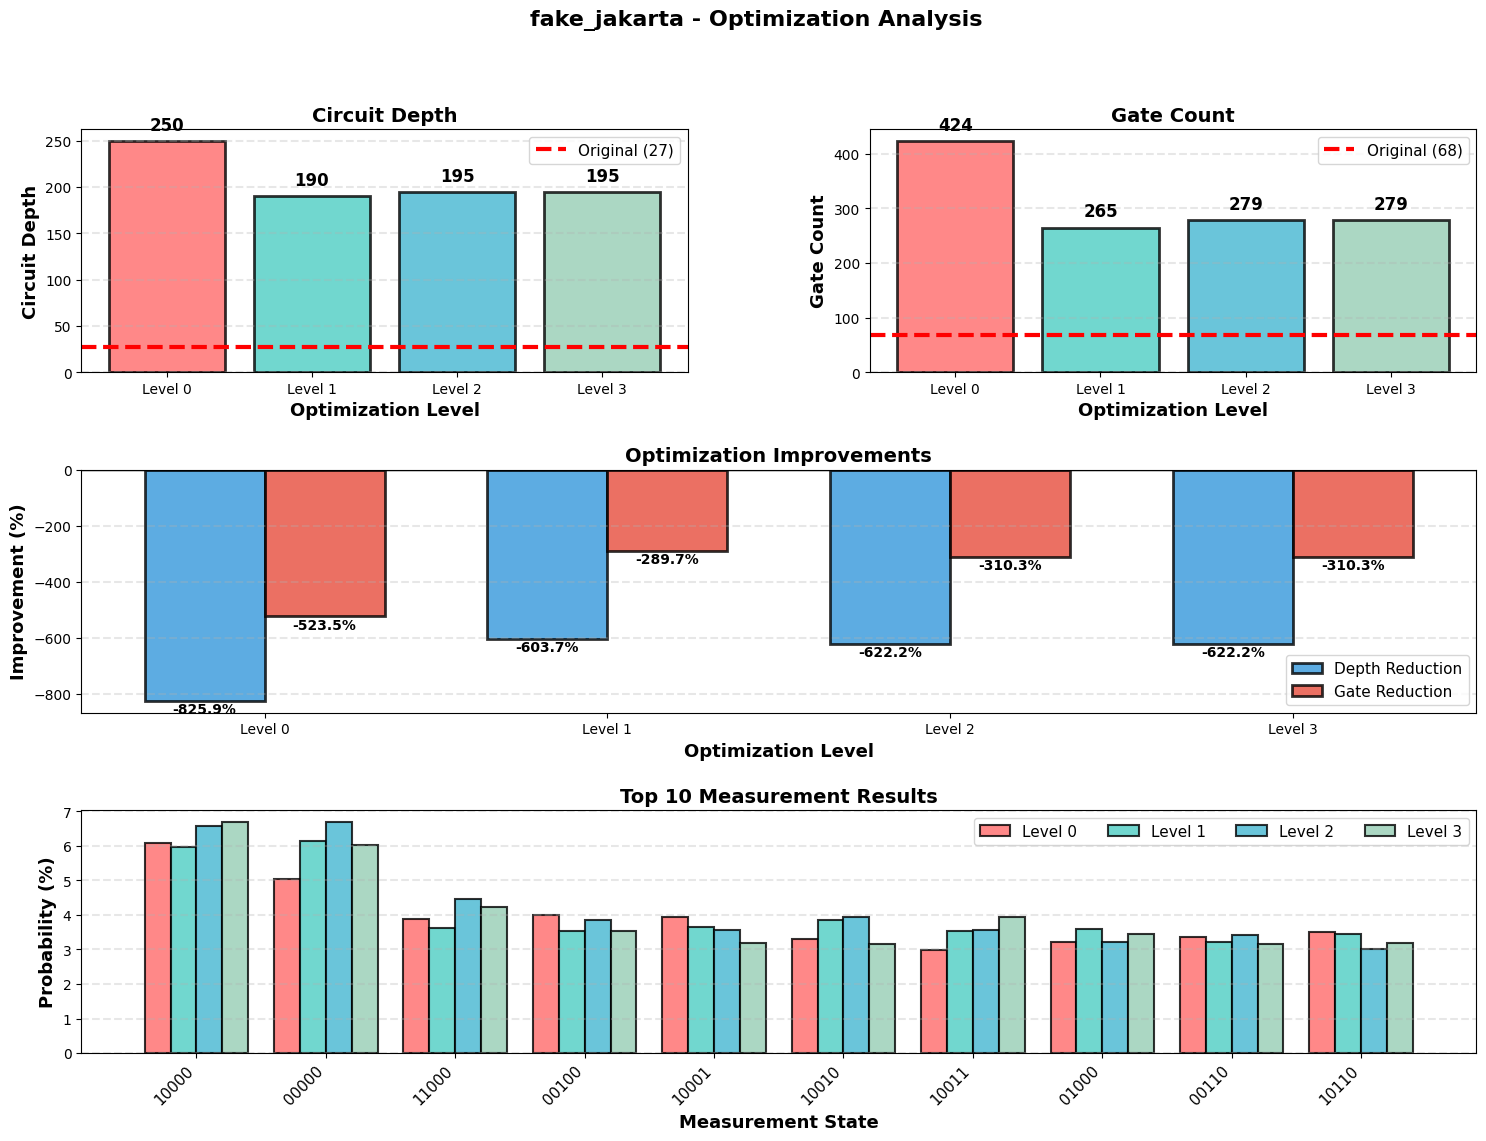

STATISTICS - fake_lagos

Original: Depth=27, Gates=68

Transpiled:
  Level 0: Depth=250, Gates=424
  Level 1: Depth=190, Gates=265
  Level 2: Depth=191, Gates=277
  Level 3: Depth=191, Gates=277

TOP 5 RESULTS

Level 0:
  |10001⟩:  220 ( 5.50%) ██
  |00001⟩:  210 ( 5.25%) ██
  |10011⟩:  203 ( 5.08%) ██
  |11001⟩:  198 ( 4.95%) ██
  |00011⟩:  184 ( 4.60%) ██

Level 1:
  |10001⟩:  221 ( 5.53%) ██
  |00001⟩:  191 ( 4.78%) ██
  |10011⟩:  185 ( 4.62%) ██
  |00011⟩:  183 ( 4.58%) ██
  |11001⟩:  180 ( 4.50%) ██

Level 2:
  |00001⟩:  230 ( 5.75%) ██
  |10001⟩:  225 ( 5.62%) ██
  |10011⟩:  205 ( 5.12%) ██
  |11001⟩:  193 ( 4.83%) ██
  |11011⟩:  168 ( 4.20%) ██

Level 3:
  |00001⟩:  230 ( 5.75%) ██
  |10001⟩:  220 ( 5.50%) ██
  |10011⟩:  195 ( 4.88%) ██
  |00011⟩:  191 ( 4.78%) ██
  |11001⟩:  188 ( 4.70%) ██




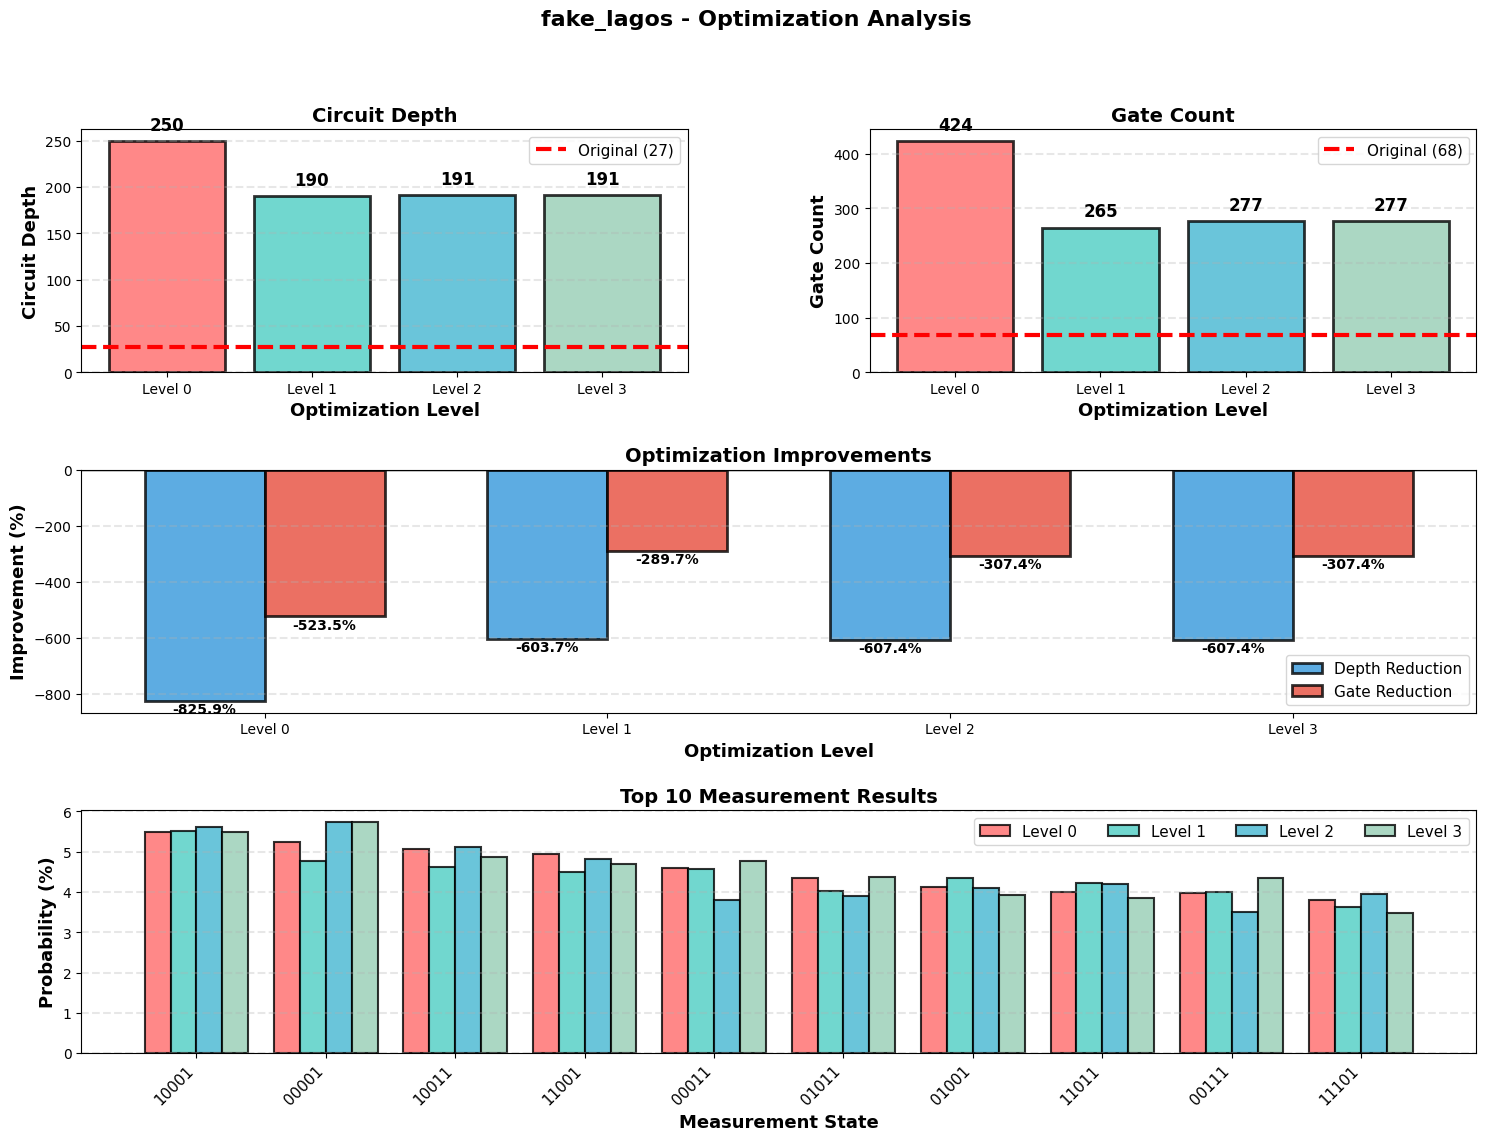

In [4]:
if 'selected_backends' not in globals() or not selected_backends:
    print("❌ ERROR: Please run previous cells first!")
else:
    for backend in selected_backends:
        backend_name = backend.name
        transpiled_circuits = backend_results[backend_name]['transpiled_circuits']
        results_dict = backend_results[backend_name]['results_dict']
        
        # Statistics
        print("=" * 80)
        print(f"STATISTICS - {backend_name}")
        print("=" * 80)
        print(f"\nOriginal: Depth={grover.depth()}, Gates={grover.size()}")
        print("\nTranspiled:")
        for level in OPTIMIZATION_LEVELS:
            if level in transpiled_circuits:
                circuit = transpiled_circuits[level]
                print(f"  Level {level}: Depth={circuit.depth()}, Gates={circuit.size()}")
        
        # Top results
        print("\n" + "=" * 80)
        print("TOP 5 RESULTS")
        print("=" * 80)
        
        for level in OPTIMIZATION_LEVELS:
            if level in results_dict and results_dict[level]:
                counts = results_dict[level]
                top_5 = dict(sorted(counts.items(), key=lambda x: x[1], reverse=True)[:5])
                
                print(f"\nLevel {level}:")
                for state, count in top_5.items():
                    prob = (count / SHOTS) * 100
                    bar = '█' * int(prob / 2)
                    print(f"  |{state}⟩: {count:4d} ({prob:5.2f}%) {bar}")
        
        print("\n")
        
        # Visualization
        fig = plt.figure(figsize=(18, 12))
        gs = fig.add_gridspec(3, 2, hspace=0.4, wspace=0.3)
        
        colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']
        
        # Depth comparison
        ax1 = fig.add_subplot(gs[0, 0])
        depths = [transpiled_circuits[l].depth() for l in OPTIMIZATION_LEVELS if l in transpiled_circuits]
        labels = [f"Level {l}" for l in OPTIMIZATION_LEVELS if l in transpiled_circuits]
        
        bars1 = ax1.bar(labels, depths, color=colors, alpha=0.8, edgecolor='black', linewidth=2)
        ax1.axhline(y=grover.depth(), color='red', linestyle='--', label=f'Original ({grover.depth()})', linewidth=3)
        ax1.set_ylabel('Circuit Depth', fontsize=13, fontweight='bold')
        ax1.set_xlabel('Optimization Level', fontsize=13, fontweight='bold')
        ax1.set_title('Circuit Depth', fontsize=14, fontweight='bold')
        ax1.legend(loc='upper right', fontsize=11)
        ax1.grid(axis='y', alpha=0.3, linestyle='--', linewidth=1.5)
        
        for bar, depth in zip(bars1, depths):
            ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(depths) * 0.03, 
                    str(depth), ha='center', va='bottom', fontweight='bold', fontsize=12)
        
        # Gate count comparison
        ax2 = fig.add_subplot(gs[0, 1])
        gate_counts = [transpiled_circuits[l].size() for l in OPTIMIZATION_LEVELS if l in transpiled_circuits]
        
        bars2 = ax2.bar(labels, gate_counts, color=colors, alpha=0.8, edgecolor='black', linewidth=2)
        ax2.axhline(y=grover.size(), color='red', linestyle='--', label=f'Original ({grover.size()})', linewidth=3)
        ax2.set_ylabel('Gate Count', fontsize=13, fontweight='bold')
        ax2.set_xlabel('Optimization Level', fontsize=13, fontweight='bold')
        ax2.set_title('Gate Count', fontsize=14, fontweight='bold')
        ax2.legend(loc='upper right', fontsize=11)
        ax2.grid(axis='y', alpha=0.3, linestyle='--', linewidth=1.5)
        
        for bar, count in zip(bars2, gate_counts):
            ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(gate_counts) * 0.03, 
                    str(count), ha='center', va='bottom', fontweight='bold', fontsize=12)
        
        # Improvement percentages
        ax3 = fig.add_subplot(gs[1, :])
        
        depth_impr = [(1 - transpiled_circuits[l].depth() / grover.depth()) * 100 
                      for l in OPTIMIZATION_LEVELS if l in transpiled_circuits]
        gate_impr = [(1 - transpiled_circuits[l].size() / grover.size()) * 100 
                     for l in OPTIMIZATION_LEVELS if l in transpiled_circuits]
        
        x = np.arange(len(labels))
        width = 0.35
        
        bars_d = ax3.bar(x - width/2, depth_impr, width, label='Depth Reduction', 
                         color='#3498db', alpha=0.8, edgecolor='black', linewidth=2)
        bars_g = ax3.bar(x + width/2, gate_impr, width, label='Gate Reduction', 
                         color='#e74c3c', alpha=0.8, edgecolor='black', linewidth=2)
        
        ax3.axhline(y=0, color='black', linestyle='-', linewidth=1)
        ax3.set_ylabel('Improvement (%)', fontsize=13, fontweight='bold')
        ax3.set_xlabel('Optimization Level', fontsize=13, fontweight='bold')
        ax3.set_title('Optimization Improvements', fontsize=14, fontweight='bold')
        ax3.set_xticks(x)
        ax3.set_xticklabels(labels)
        ax3.legend(fontsize=11, loc='best')
        ax3.grid(axis='y', alpha=0.3, linestyle='--', linewidth=1.5)
        
        for bars in [bars_d, bars_g]:
            for bar in bars:
                height = bar.get_height()
                label_y = height + (2 if height > 0 else -5)
                ax3.text(bar.get_x() + bar.get_width()/2, label_y, 
                        f'{height:.1f}%', ha='center', va='bottom' if height > 0 else 'top', 
                        fontweight='bold', fontsize=10)
        
        # Measurement results
        ax4 = fig.add_subplot(gs[2, :])
        
        all_states = sorted(set().union(*[set(results_dict[l].keys()) 
                                           for l in OPTIMIZATION_LEVELS if l in results_dict]))
        
        if len(all_states) > 10:
            state_totals = {s: sum(results_dict[l].get(s, 0) for l in OPTIMIZATION_LEVELS if l in results_dict) 
                            for s in all_states}
            all_states = sorted(state_totals, key=state_totals.get, reverse=True)[:10]
        
        x_pos = np.arange(len(all_states))
        bar_width = 0.2
        
        for idx, level in enumerate(OPTIMIZATION_LEVELS):
            if level in results_dict and results_dict[level]:
                counts = results_dict[level]
                probs = [counts.get(s, 0) / SHOTS * 100 for s in all_states]
                offset = bar_width * (idx - 1.5)
                ax4.bar(x_pos + offset, probs, bar_width, label=f'Level {level}', 
                        color=colors[idx], alpha=0.8, edgecolor='black', linewidth=1.5)
        
        ax4.set_xlabel('Measurement State', fontsize=13, fontweight='bold')
        ax4.set_ylabel('Probability (%)', fontsize=13, fontweight='bold')
        ax4.set_title('Top 10 Measurement Results', fontsize=14, fontweight='bold')
        ax4.set_xticks(x_pos)
        ax4.set_xticklabels(all_states, rotation=45, ha='right', fontsize=11)
        ax4.legend(loc='upper right', fontsize=11, ncol=4)
        ax4.grid(axis='y', alpha=0.3, linestyle='--', linewidth=1.5)
        
        plt.suptitle(f'{backend_name} - Optimization Analysis', fontsize=16, fontweight='bold')
        plt.show()